In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn import datasets, decomposition

In [83]:
data = pd.read_csv('heart.csv')

In [84]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [85]:
data.shape

(918, 12)

In [86]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

Age: age of the patient [years]
Sex: sex of the patient [M: Male, F: Female]
ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
RestingBP: resting blood pressure [mm Hg]
Cholesterol: serum cholesterol [mm/dl]
FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
Oldpeak: oldpeak = ST [Numeric value measured in depression]
ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
HeartDisease: output class [1: heart disease, 0: Normal]

In [87]:
# checking for total null values

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [88]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [89]:
col = list(data.columns)
categorical_features = []
numerical_features = []
for i in col:
    if len(data[i].unique()) > 6:
        numerical_features.append(i)
    else:
        categorical_features.append(i)

print('Categorical Features :',*categorical_features)
print('Numerical Features :',*numerical_features)

Categorical Features : Sex ChestPainType FastingBS RestingECG ExerciseAngina ST_Slope HeartDisease
Numerical Features : Age RestingBP Cholesterol MaxHR Oldpeak


**Distribution of Categorical Features**

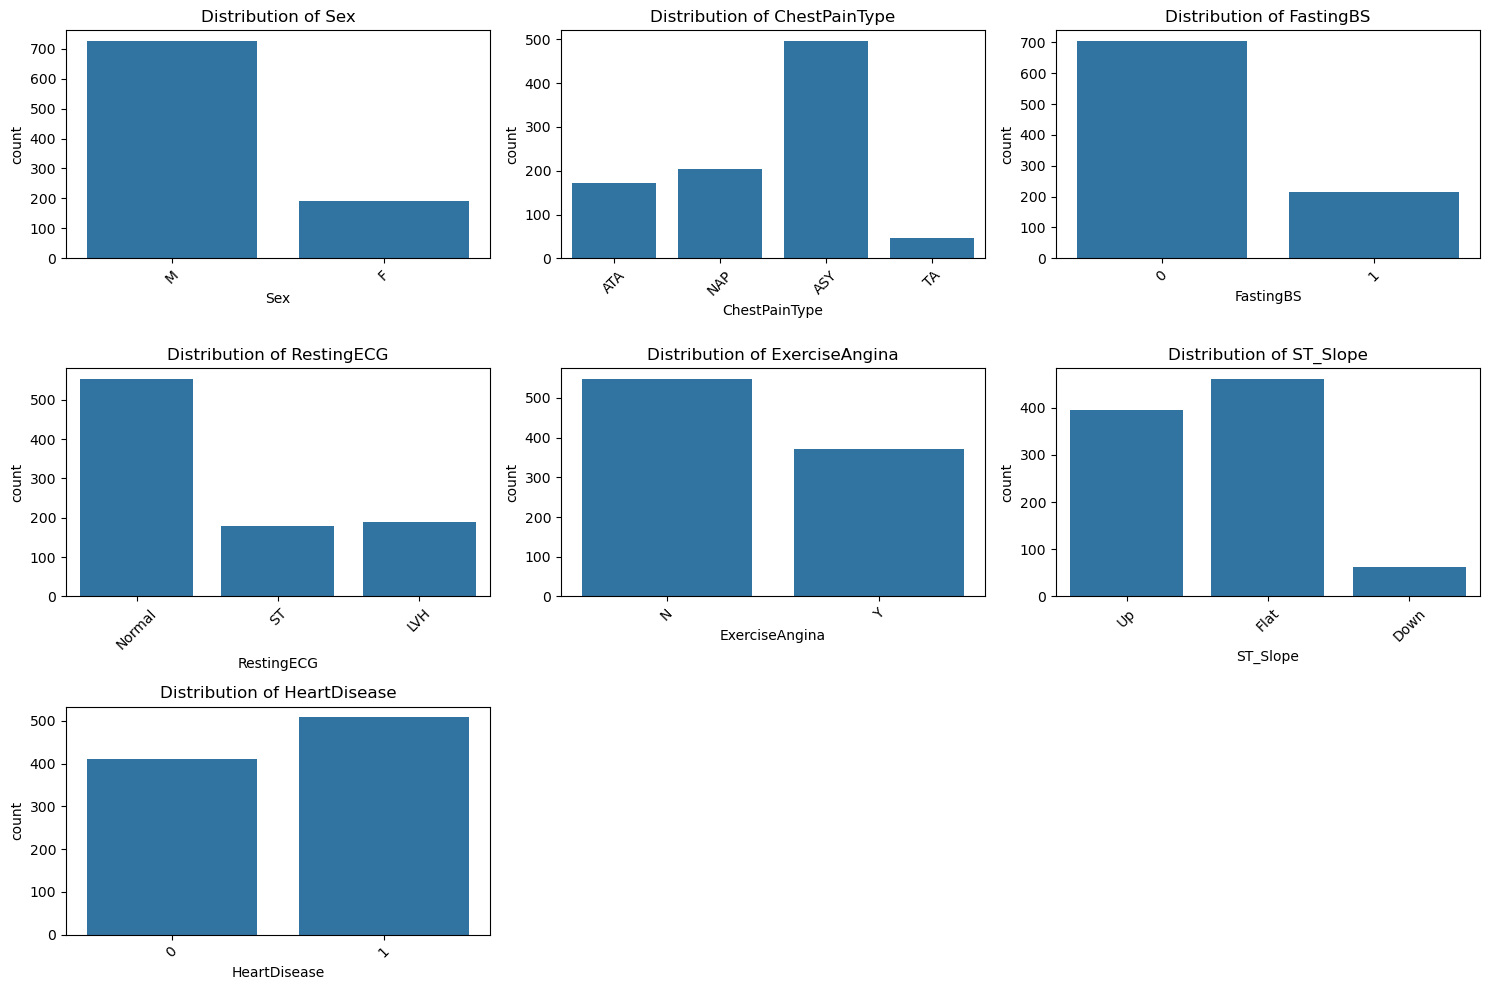

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns


cat_cols = categorical_features


plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_cols, 1):
    plt.subplot((len(cat_cols)+2)//3, 3, i)
    sns.countplot(data=data, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Distribution of Numerical Features**

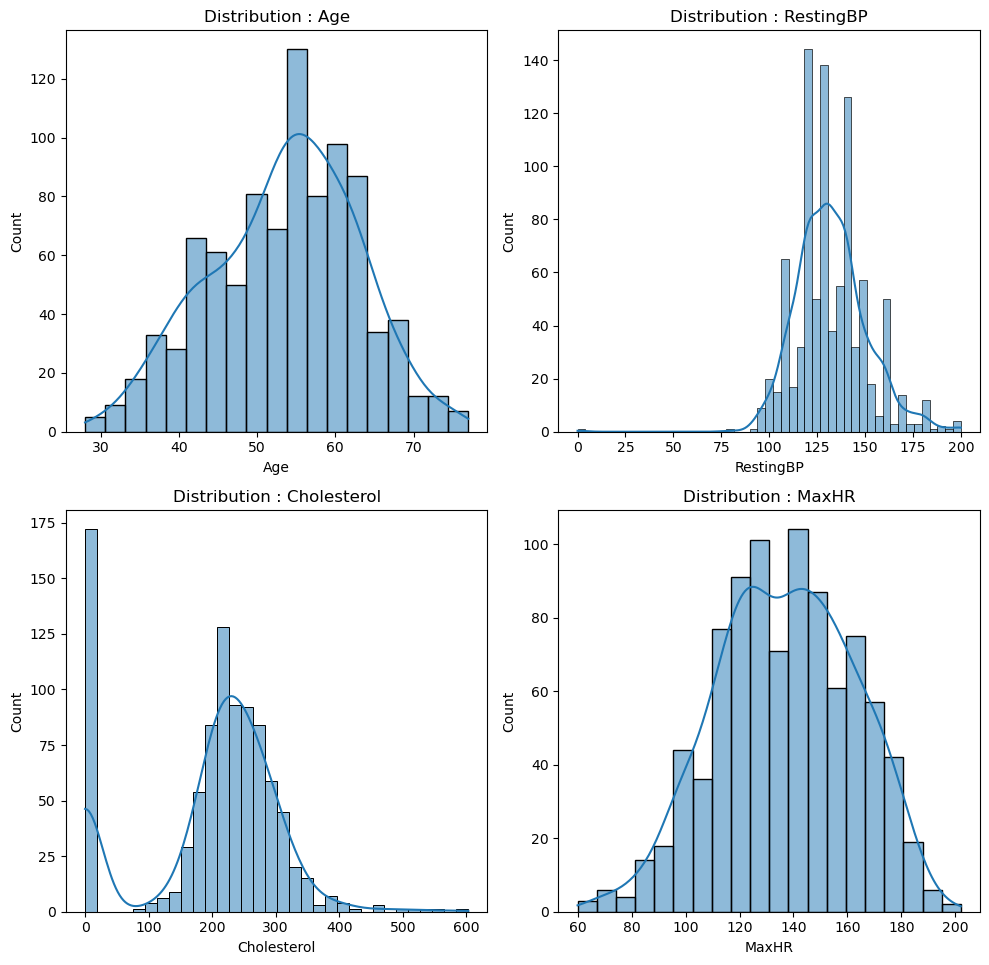

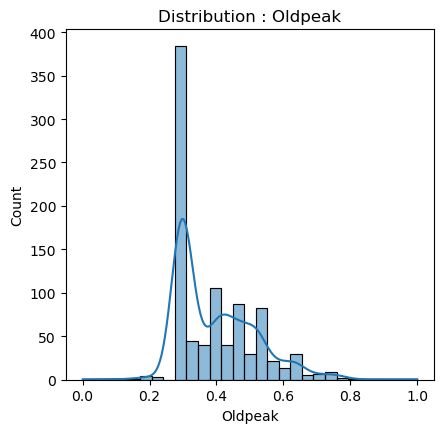

In [91]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 9.75))

for i in range(len(numerical_features) - 1):
    plt.subplot(2, 2, i + 1)
    sns.histplot(
        data=data[numerical_features[i]],
        kde=True
    )
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)

plt.tight_layout()
plt.show()


plt.figure(figsize=(4.75, 4.55))
sns.histplot(
    data=df1[numerical_features[len(numerical_features) - 1]],
    kde=True
)

title = 'Distribution : ' + numerical_features[len(numerical_features) - 1]
plt.title(title)
plt.show()

Cholestrol has a bidmodal data distribution.   
Oldpeak - not normal distribution.

C:\Users\Ast\AppData\Local\Temp\ipykernel_5048\2863344355.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Heart Disease','Heart Disease'])


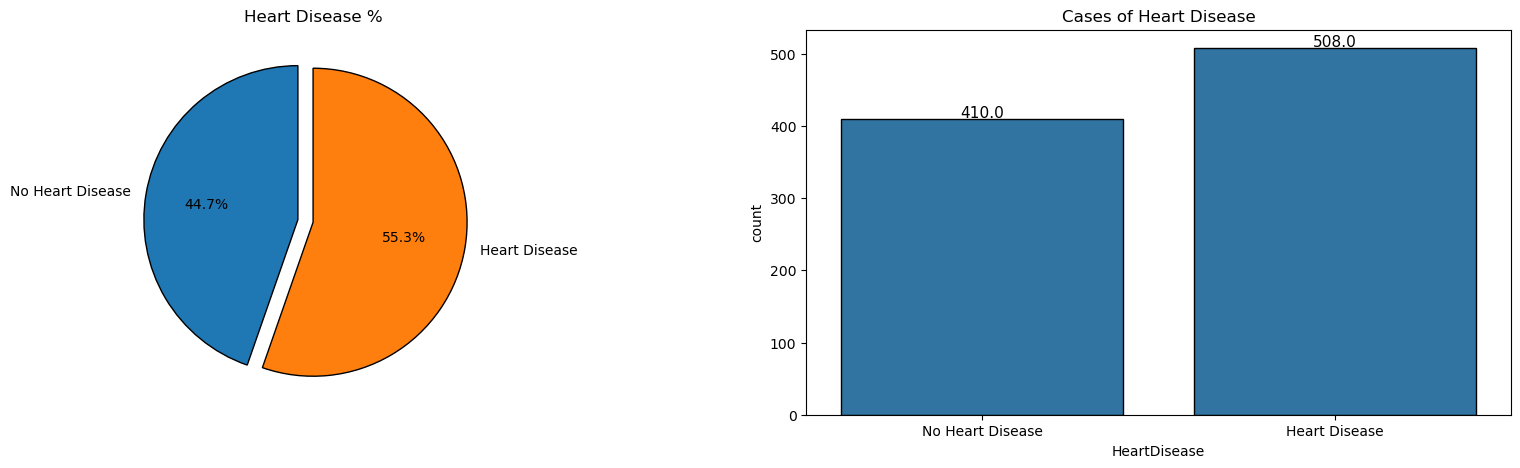

In [92]:
l = list(data['HeartDisease'].value_counts())
circle = [l[1] / sum(l) * 100,l[0] / sum(l) * 100]

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (20,5))
plt.subplot(1,2,1)
plt.pie(circle,labels = ['No Heart Disease','Heart Disease'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),
        wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Heart Disease %');

plt.subplot(1,2,2)
ax = sns.countplot(x ='HeartDisease',data = data,edgecolor = 'black')
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize = 11)
ax.set_xticklabels(['No Heart Disease','Heart Disease'])
plt.title('Cases of Heart Disease');
plt.show()

classes are balanced

**multiple pairwise bivariate distributions**

[]

<Figure size 1500x1000 with 0 Axes>

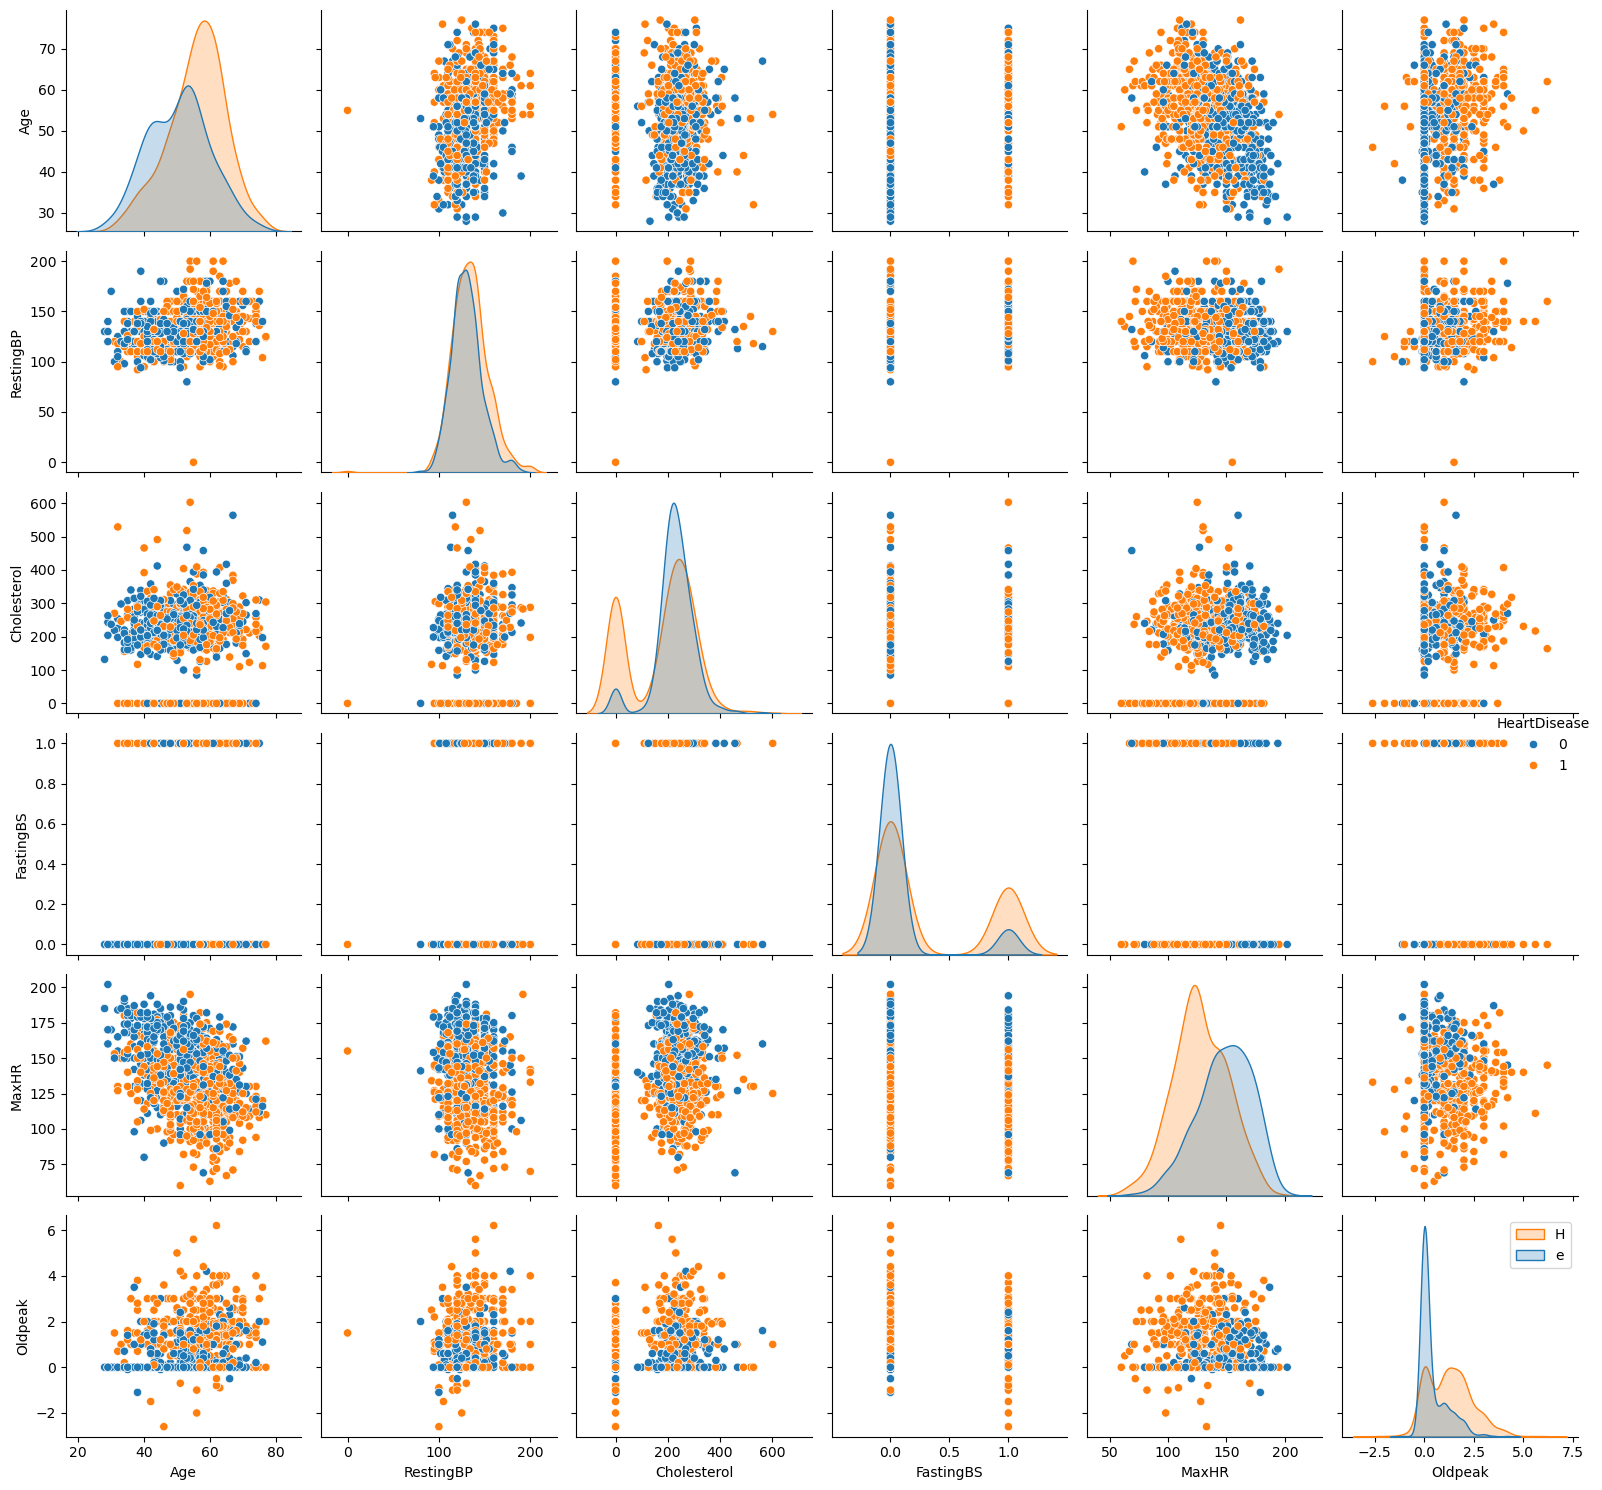

In [93]:
plt.figure(figsize=(15,10))
sns.pairplot(data,hue="HeartDisease")

plt.legend("HeartDisease")
plt.tight_layout()
plt.plot()

**Correlation Matrix**

<Axes: >

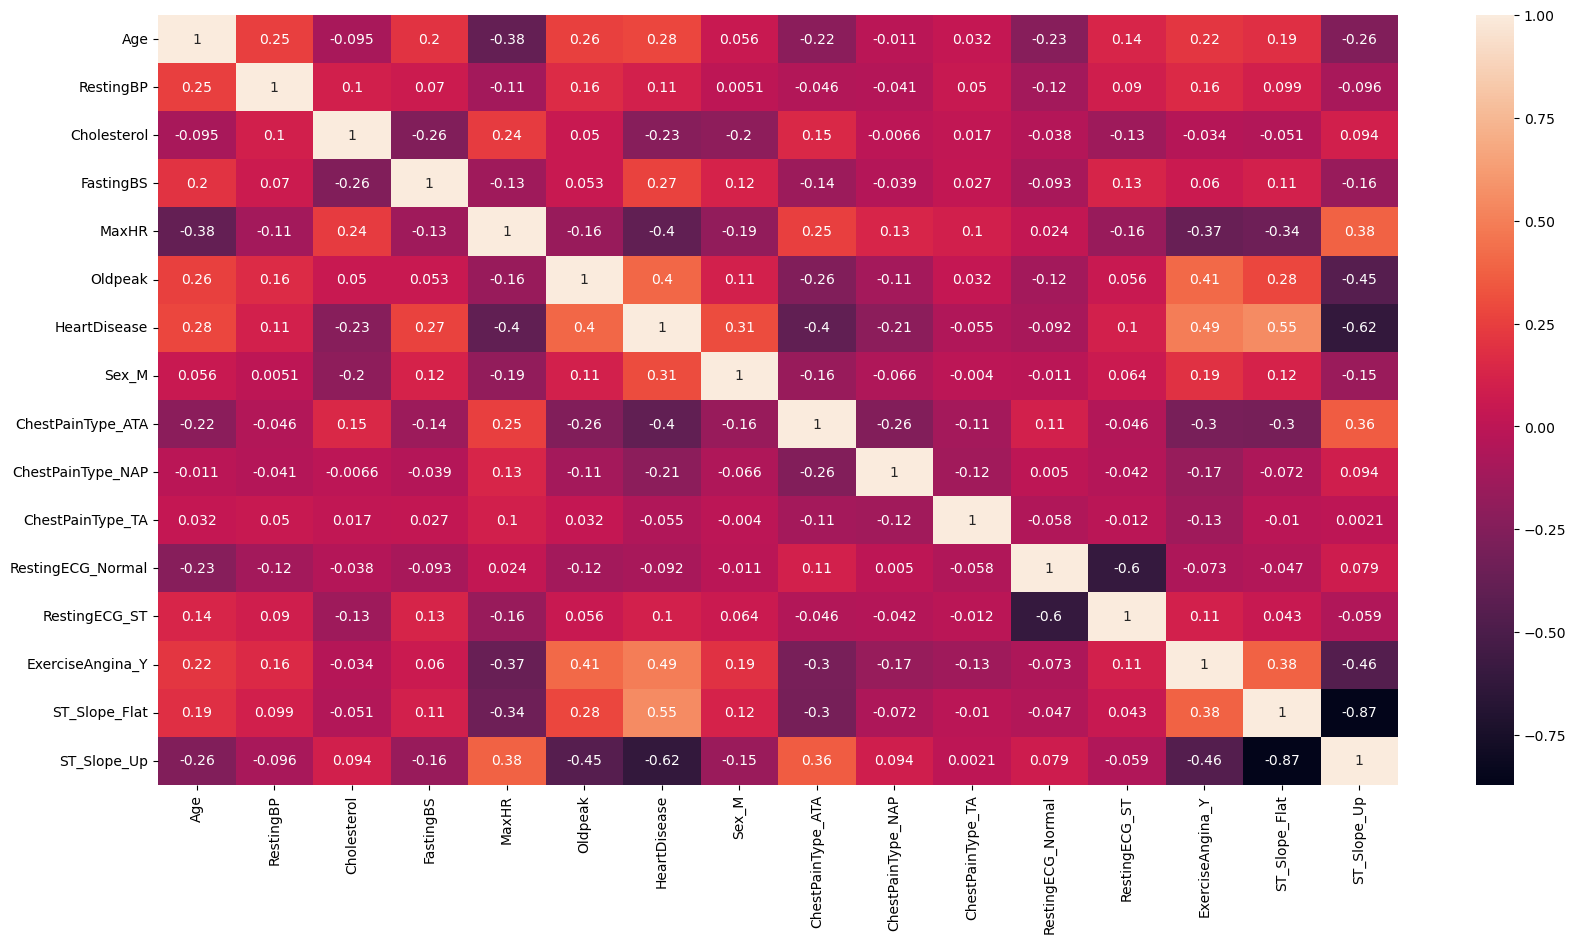

In [99]:
plt.figure(figsize = (20,10))
sns.heatmap(df1.corr(),annot = True)

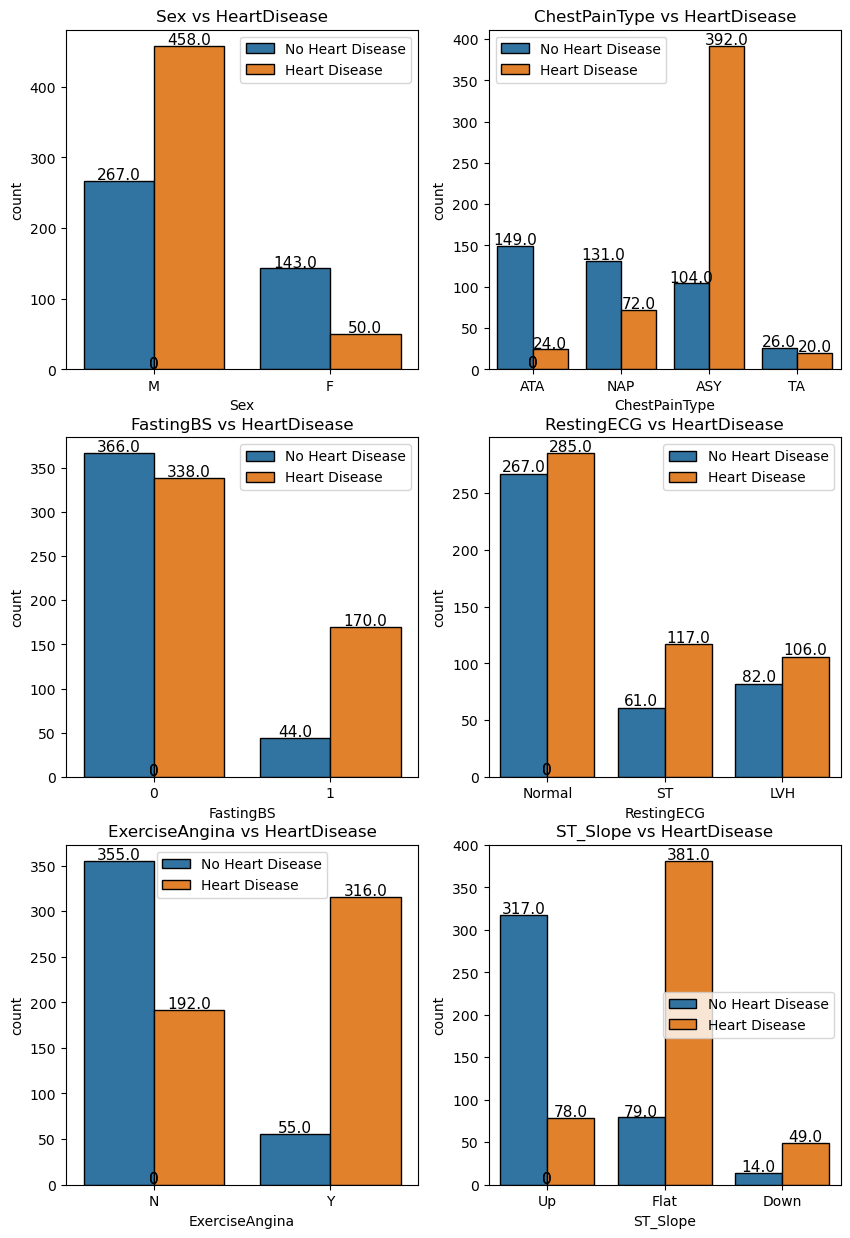

In [95]:
fig, ax = plt.subplots(nrows = 3,ncols = 2,figsize = (10,15))
for i in range(len(categorical_features) - 1):
    plt.subplot(3,2,i+1)
    ax = sns.countplot(x=categorical_features[i],data = data,hue = "HeartDisease",edgecolor = 'black')
    for rect in ax.patches:
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize = 11)
    title = categorical_features[i] + ' vs HeartDisease'
    plt.legend(['No Heart Disease','Heart Disease'])
    plt.title(title)

1)Among the male population, the number of patients with heart disease is higher than those without it. In contrast, among females, the number of patients without heart disease exceeds those with the condition.    
Male > Female for  for positive cases of heart disease                                                       
2)The ASY type of chest pain strongly indicates a high likelihood of heart disease.  
people with ASY type chest pain are more common than others  
ChestPainType : ASY > NAP > ATA > TA   for positive cases of heart disease      
3)Fasting Blood Sugar does not show a clear pattern: both patients with normal and elevated levels include a significant number of heart disease cases.  
( FBS < 120 mg/dl ) > ( FBS > 120 mg/dl) for  for positive cases of heart disease                   
4)RestingECG does not clearly distinguish a single category associated with heart disease, as all three categories contain a substantial number of affected patients.  
Normal > ST > LVH  for  for positive cases of heart disease         
5)Exercise-induced angina clearly increases the probability of being diagnosed with heart disease.  
Angina > No Angina   for  for positive cases of heart disease                
6)Regarding ST_Slope, the Flat type shows a strong association with heart disease and a high probability of diagnosis. The Down type exhibits a similar tendency, although it is represented by a smaller number of observations.
Flat > Up > Down  for positive cases of heart disease  

**Feature Engineering**    
Data Scaling 

In [96]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df1 = data.copy(deep=True)

df1 = pd.get_dummies(
    df1,
    columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'],
    drop_first=True,
    dtype=int
)


mms = MinMaxScaler()
ss = StandardScaler()

# features
minmax_cols = ['Oldpeak']
standard_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']


df1[minmax_cols] = mms.fit_transform(df1[minmax_cols])
df1[standard_cols] = ss.fit_transform(df1[standard_cols])

df1.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.410909,0.825070,0,1.382928,0.295455,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.491752,-0.171961,0,0.754157,0.409091,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.129513,0.770188,0,-1.525138,0.295455,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.302825,0.139040,0,-1.132156,0.465909,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.951331,-0.034755,0,-0.581981,0.295455,0,1,0,1,0,1,0,0,0,1
